# 12. Latent Dirichlet Allocation — Ejemplo de Topic Modeling sobre noticias

* En el siguiente ejemplo vamos a ver cómo ***obtener los temas (Topics) de una serie de artículos (noticias)*** que están etiquetados con un tema (el corpus tiene 20 temas).


* ***IMPORTANTE***: *Esto es aprendizaje no supervisado, por lo que no tenemos que tener en cuenta los temas en los que alguien (un humano experto) ha clasificado estos textos. La idea del ejercicio es obtener los temas distintos de los que hablan los artículos (***clusterizar artículos***); nos es útil saber a priori el número de temas distintos que puede tener, pero en ningún caso el target de los artículos entra al algoritmo de aprendizaje (LDA en este caso).*


* Para realizar este ejercicio seguiremos los siguientes pasos:
    1. Carga de datos
    2. Normalización de textos
    3. Creación del diccionario y la bolsa de palabras
    4. Creación del modelo
    5. Visualización
    6. Selección del número óptimo de topics (coherencia)
    7. Creación del modelo y visualización con el número de temas óptimo

<hr>

## 1. Carga de datos

* El fichero en formato JSON contiene una serie de documentos a los que se les asigna una temática.


* Cada elemento del JSON contiene:
    - **content**: Contenido del artículo
    - **target**: Identificador del target
    - **target_names**: Nombre del target


* Leemos los datos y mostramos una muestra:

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

df = pd.read_json('corpus/newsgroups.json')
corpus = df.content.values
df.sample(5)

,content,target,target_names
902,From: thouchin@cs.umr.edu (T. J. Houchin)\nSub...,6,misc.forsale
10623,From: PA146008@utkvm1.utk.edu (David Veal)\nSu...,16,talk.politics.guns
1702,From: bgendler@opus.starlab.CSc.COM (Bruce Gen...,5,comp.windows.x
9464,From: m14494@mwvm.mitre.org (Mike White)\nSubj...,6,misc.forsale
1529,From: feilimau@leland.Stanford.EDU (Christophe...,4,comp.sys.mac.hardware


* Los documentos se han clasificado en 20 temas, lo cual nos puede dar una pista para seleccionar el número de temas a priori:

In [2]:
df.groupby(['target', 'target_names']).size()

target  target_names            
0       alt.atheism                  92
1       comp.graphics               120
2       comp.os.ms-windows.misc     122
3       comp.sys.ibm.pc.hardware    138
4       comp.sys.mac.hardware       122
5       comp.windows.x              135
6       misc.forsale                145
7       rec.autos                   137
8       rec.motorcycles             118
9       rec.sport.baseball          125
10      rec.sport.hockey            140
11      sci.crypt                   152
12      sci.electronics             128
13      sci.med                     124
14      sci.space                   153
15      soc.religion.christian      137
16      talk.politics.guns          105
17      talk.politics.mideast       129
18      talk.politics.misc           91
19      talk.religion.misc           87
dtype: int64

<hr>

## 2. Normalización

* Utilizamos ***spaCy*** para la tokenización y normalización. Como el corpus está en inglés, cargamos el modelo `en_core_web_sm`.


* Para ***normalizar*** los artículos realizaremos las siguientes acciones:
    1. Pasamos las frases a minúsculas.
    2. Eliminamos los signos de puntuación.
    3. Eliminamos las palabras con menos de 3 caracteres.
    4. Eliminamos las palabras con más de 10 caracteres.
    5. Eliminamos las stop-words.
    6. Eliminamos los emails.
    7. Eliminamos los saltos de línea.
    8. Eliminamos las comillas simples.
    9. Filtramos las palabras que no sean Nombre, Adjetivo, Verbo o Adverbio.
    10. Pasamos la palabra a su lema.


* Todos estos pasos los vamos a realizar en una misma función.

In [3]:
import re
import spacy

from tqdm import tqdm

nlp = spacy.load('en_core_web_sm')


def normalize(corpus):
    """Normalizamos la lista de frases y devolvemos la misma lista de frases normalizada"""
    for index, doc in enumerate(tqdm(corpus)):
        doc = nlp(doc.lower())
        corpus[index] = ' '.join([word.lemma_ for word in doc if (not word.is_punct)
                                  and (len(word.text) > 2)
                                  and (len(word.text) < 11)
                                  and (not word.is_stop)
                                  and re.sub(r'\S*@\S*\s?', '', word.text)
                                  and re.sub(r'\s+', ' ', word.text)
                                  and re.sub(r"'", '', word.text)
                                  and not word.text.startswith('|')
                                  and (word.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV'])])

    return corpus


# Normalizamos las frases
corpus_norm = normalize(corpus)

100%|██████████| 2500/2500 [04:38<00:00,  8.99it/s]


<hr>

## 3. Creación del diccionario y la bolsa de palabras (BoW)

* En este punto tenemos que crear:
    - Corpus tokenizado: `documents_tok`
    - Diccionario: `dictionary`
    - Corpus: `corpus_bow`, que es la bolsa de palabras de Gensim

In [4]:
from pprint import pprint
from gensim import corpora
from collections import defaultdict

# Tokenizamos
documents_tok = [doc.split() for doc in corpus_norm]

# Creamos el diccionario (vocabulario)
frequency = defaultdict(int)
for doc in documents_tok:
    for token in doc:
        frequency[token] += 1

documents = [[token for token in doc] for doc in documents_tok]
dictionary = corpora.Dictionary(documents)
print('Diccionario:\n{}'.format(dictionary))

# Creamos la Bolsa de Palabras
corpus_bow = [dictionary.doc2bow(doc) for doc in documents]
print('\nPrimer documento del corpus:\n{}'.format(corpus_bow[0]))

Diccionario:
Dictionary<20198 unique tokens: ['address', 'api', 'article', 'ask', 'assume']...>

Primer documento del corpus:
[(0, 3), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 3), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 2), (33, 1), (34, 2), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 2)]


<hr>

## 4. Creación del modelo

* A priori vamos a crear un modelo con 20 topics, que es el número de temas en los que un humano ha clasificado los textos.


* Dado que estamos trabajando con un corpus relativamente grande (2500 documentos), tenemos que pasarle a la implementación del modelo algunos parámetros para optimizar la ejecución; por ejemplo, `chunksize=100` para que vaya entrenando el modelo de 100 en 100 documentos.


* Para más información ver la documentación: https://radimrehurek.com/gensim/models/ldamodel.html

In [5]:
warnings.filterwarnings('ignore')
from gensim.models import LdaModel

lda_model = LdaModel(corpus=corpus_bow,
                     id2word=dictionary,
                     num_topics=20,
                     random_state=100,
                     chunksize=100,
                     passes=10,
                     alpha='auto',
                     per_word_topics=True)

<hr>

## 5. Visualización

* Pasamos a visualizar los resultados con la librería `pyLDAvis`.


* Con los resultados obtenidos podemos observar que hay temas (topics) muy similares entre sí, ya que las burbujas que representan los topics están "apelotonadas" entre sí, lo que significa que esos temas están caracterizados por palabras comunes entre ellos.


* Con esta visualización podemos observar que hay temas muy relacionados entre sí y que probablemente hablen de lo mismo, por lo que deberíamos seleccionar menos temas.

In [6]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

vis = gensimvis.prepare(lda_model, corpus_bow, dictionary)
pyLDAvis.display(vis)

<hr>

# <span style="color:red">Selección del número óptimo de Topics (coherencia)</span>

* Dado que las técnicas de "Topic Modeling" (tanto LSI como LDA) ***generan automáticamente 'N' temas (Topics)*** a partir de los documentos del corpus ***de forma no supervisada***, tenemos que evaluar de alguna manera si los temas que genera son "***coherentes***" entre sí; es decir, si hay dos o más temas tan similares entre sí que podrían formar uno solo, o si hay temas muy genéricos que podrían dividirse en dos o más temas.


* Este es un problema común que también tenemos las personas a la hora de ***asignar un tema a un texto, ya que se trata de una tarea que en ocasiones puede ser muy subjetiva***.


* Por este motivo es necesario cuantificar un nivel de ***coherencia*** sobre la segmentación realizada.


* Para hacer una analogía con clustering, la ***coherencia*** en el Topic Modeling viene a ser como la ***inercia*** en el K-Means.


* La ***coherencia*** es, por tanto, una medida que ***nos sirve para ver lo bien o mal que están definidos los temas (topics) por sus palabras (terms) más representativas del topic***.


* Para más información ver el siguiente artículo: http://svn.aksw.org/papers/2015/WSDM_Topic_Evaluation/public.pdf


### ¿Cómo se calcula la coherencia?

* La coherencia de un modelo se calcula, dadas las 'N' palabras más relevantes de un tema (Topic), como:


$$ coherence = \sum_{i>j} score(w_{i},w_{j})$$


* Siendo w<sub>i</sub> y w<sub>j</sub> dos pares de palabras relevantes del tema (Topic).


* Existen dos métodos para el cálculo del ***score*** de la coherencia:
    - Extrinsic UCI measure
    - Intrinsic UMass measure


* Antes de explicar cómo se calcula el score definimos:

    - **D**: Número de documentos del corpus.
    - **D(w<sub>i</sub>)**: Número de documentos en los que aparece la palabra w<sub>i</sub> en el corpus.
    - **D(w<sub>i</sub>, w<sub>j</sub>)**: Número de documentos en los que aparecen conjuntamente las palabras w<sub>i</sub> y w<sub>j</sub> en el corpus.
    - **p(w<sub>i</sub>)**: Probabilidad de que aparezca la palabra w<sub>i</sub> en un documento del corpus:

    $$p(w_{i}) = \frac{D(w_{i})}{D}$$

    - **p(w<sub>i</sub>, w<sub>j</sub>)**: Probabilidad de que aparezcan conjuntamente las palabras w<sub>i</sub> y w<sub>j</sub> en un documento del corpus:

    $$p(w_{i}, w_{j}) = \frac{D(w_{i}, w_{j})}{D}$$

* ***Score: Extrinsic UCI measure***

    $$score_{c\_uci} (w_{i}, w_{j}) = log \frac{p(w_{i},w_{j})}{p(w_{i}) p(w_{j})}$$

* ***Score: Intrinsic UMass measure***

    $$score_{c\_mass} (w_{i}, w_{j}) = log \frac{D(w_{i},w_{j}) + 1}{D(w_{i})}$$


* Veamos a continuación cómo calcular la coherencia para diferentes modelos de LDA que van desde 5 a 25 temas (topics):

In [7]:
warnings.filterwarnings('ignore')
from gensim.models import CoherenceModel

coherence = []
min_topics = 5
max_topics = 26
for num_topics in tqdm(range(min_topics, max_topics, 1)):
    lda_model_tmp = LdaModel(corpus=corpus_bow,
                             id2word=dictionary,
                             num_topics=num_topics,
                             random_state=0,
                             chunksize=100,
                             passes=10,
                             alpha='auto',
                             per_word_topics=True)
    coherencemodel = CoherenceModel(model=lda_model_tmp, texts=documents_tok, dictionary=dictionary, coherence='u_mass')
    coherence.append(coherencemodel.get_coherence())

100%|██████████| 21/21 [05:04<00:00, 14.52s/it]


In [8]:
index = ['Num Topics: {num}'.format(num=num) for num in range(min_topics, max_topics, 1)]
pd.DataFrame(coherence, index=index, columns=['Coherence'])

,Coherence
Num Topics: 5,-3.931300
Num Topics: 6,-2.325672
Num Topics: 7,-3.314937
Num Topics: 8,-3.468518
Num Topics: 9,-4.643707
Num Topics: 10,-5.220285
Num Topics: 11,-5.497805
Num Topics: 12,-5.467544
Num Topics: 13,-6.545590
Num Topics: 14,-6.019959


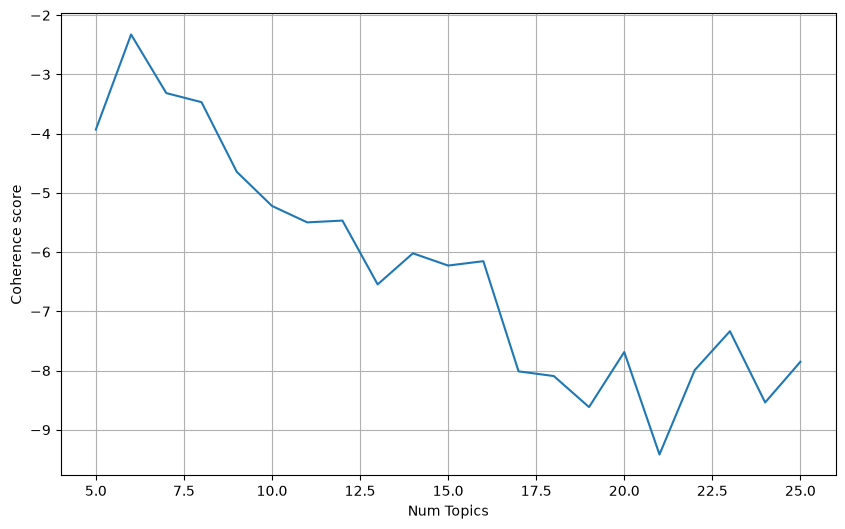

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 6))
plt.plot(range(min_topics, max_topics, 1), coherence)
plt.xlabel('Num Topics')
plt.ylabel('Coherence score')
plt.grid()
plt.show()

<hr>

## 7. Creación del modelo y visualización con el número de temas óptimo

* Con los resultados obtenidos de la coherencia identificamos el número de temas que maximiza el score (el valor menos negativo, ya que la medida UMass es siempre negativa o cero).


* No existe una norma que diga que la mejor división de temas de un corpus es aquella que mayor valor de coherencia tiene. Cuantos más temas, menor coherencia tendremos, pero más dividiremos nuestro corpus, y viceversa.


* La gráfica anterior nos permite identificar, además del máximo global, otros máximos locales que también representan divisiones razonables del corpus.


* Veamos a continuación cómo quedarían distribuidos los temas (topics) y las palabras (terms) con el número óptimo de temas.

In [10]:
mejor_num_topics = list(range(min_topics, max_topics, 1))[int(pd.Series(coherence).idxmax())]
print(f'Número óptimo de topics (máxima coherencia): {mejor_num_topics}')
print(f'Coherencia: {max(coherence):.4f}')

Número óptimo de topics (máxima coherencia): 6
Coherencia: -2.3257


### Modelo con el número óptimo de topics

In [11]:
warnings.filterwarnings('ignore')

lda_model_optimo = LdaModel(corpus=corpus_bow,
                            id2word=dictionary,
                            num_topics=mejor_num_topics,
                            random_state=0,
                            chunksize=100,
                            passes=10,
                            alpha='auto',
                            per_word_topics=True)

vis = gensimvis.prepare(lda_model_optimo, corpus_bow, dictionary)
pyLDAvis.display(vis)

## Conclusiones

* El número de temas que un humano ha asignado al corpus (20) no tiene por qué coincidir con el número óptimo de temas que un algoritmo no supervisado como el LDA identifica como más coherente. Ambos criterios responden a objetivos distintos: la clasificación humana en 20 categorías (`alt.atheism`, `comp.graphics`, `rec.autos`...) está basada en el foro de origen de cada noticia, mientras que la coherencia mide exclusivamente si las palabras de cada topic tienden a aparecer juntas en los mismos documentos.


* Categorías temáticamente próximas en el dataset original (por ejemplo, `comp.sys.ibm.pc.hardware` y `comp.sys.mac.hardware`, o los distintos subforos de `talk.politics.*`) comparten mucho vocabulario, lo que puede hacer que el LDA las agrupe en menos temas de los 20 originales sin perder coherencia.


* Por eso es habitual que el número óptimo de topics según la coherencia sea distinto del número de categorías con el que originalmente se etiquetó el corpus, y no existe un motivo para forzar que coincidan: el Topic Modeling es una técnica de aprendizaje no supervisado y su objetivo es encontrar la estructura latente de los datos, no reproducir un etiquetado externo.


* Como en todo problema de aprendizaje no supervisado, conviene combinar la métrica cuantitativa (coherencia) con la inspección cualitativa de las palabras más representativas de cada topic (visualización con `pyLDAvis`) antes de decidir el número final de temas.